# Sentinel-2 Baseline Analysis (2020) — 7 Major OSM Road Classes

This notebook performs:
- data cleaning (including invalid/zero filtering),
- descriptive statistics (mean, std, median, IQR),
- boxplots by class,
- quarterly trend analysis,
- overall and quarterly correlation heatmaps.

Road classes:
`residential`, `service`, `unclassified`, `trunk`, `primary`, `secondary`, `tertiary`.


In [1]:
# Cell 1 — Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

DATA_DIR = Path("/Users/miranda/Documents/GitHub/Sentinel-FYP/data")

In [18]:
# Cell 2 — Load 2020 data from partitioned parquet
df = pd.read_parquet(DATA_DIR / "ghana_parquet", filters=[("year", "==", 2020)])
print("Raw rows:", len(df))
df.head()


Raw rows: 2632832


,osm_id,fclass,quarter,NDVI,NDMI,NDBI,NDWI,BSI,year
0,520162721,trunk,Q1,0.157278,-0.142099,0.142099,-0.269918,0.183079,2020
1,574240962,trunk,Q1,0.089044,-0.130132,0.130132,-0.173877,0.156009,2020
2,574240965,trunk,Q1,0.058767,-0.161057,0.161057,-0.144965,0.174362,2020
3,574240966,trunk,Q1,0.053484,-0.161021,0.161021,-0.149151,0.175833,2020
4,574240968,trunk,Q1,0.090370,-0.135617,0.135617,-0.168844,0.155728,2020


In [19]:
# Cell 3 — Standardize columns + keep required classes
rename_map = {
    "NDVI_mean": "NDVI",
    "NDMI_mean": "NDMI",
    "NDBI_mean": "NDBI",
    "NDWI_mean": "NDWI",
    "BSI_mean": "BSI",
}
df = df.rename(columns=rename_map)

required = ["osm_id", "fclass", "year", "quarter", "NDVI", "NDMI", "NDBI", "NDWI", "BSI"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

keep_classes = ["residential", "service", "unclassified", "trunk", "primary", "secondary", "tertiary"]
df = df[df["fclass"].isin(keep_classes)].copy()

print("Rows after class filter:", len(df))


Rows after class filter: 2632832


In [20]:
# Cell 4 — Time key + numeric conversion
quarter_map = {
    "Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4,
    "Jan–Mar": 1, "Apr–Jun": 2, "Jul–Sep": 3, "Oct–Dec": 4,
    "Jan-Mar": 1, "Apr-Jun": 2, "Jul-Sep": 3, "Oct-Dec": 4
}

df["qnum"] = df["quarter"].map(quarter_map)
df = df.dropna(subset=["qnum"]).copy()
df["qnum"] = df["qnum"].astype(int)
df["year"] = df["year"].astype(int)
df["t"] = pd.PeriodIndex.from_fields(year=df["year"], quarter=df["qnum"], freq="Q").to_timestamp()

for c in ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")


In [21]:
# Cell 5 — Cleaning invalid and zero values
# Assumptions:
# - Indices should be within [-1, 1]
# - dropping rows where indices are 0 (often placeholders in your exports)

df_pre_clean = df.copy()


idx_cols = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]
rows_before = len(df)

# drop NaN in any index
df = df.dropna(subset=idx_cols).copy()

# drop out-of-range
valid_mask = np.logical_and.reduce([(df[c] >= -1) & (df[c] <= 1) for c in idx_cols])
df = df[valid_mask].copy()

# drop rows with any zero in the five indices
zero_mask = (df[idx_cols] == 0).any(axis=1)
df = df[~zero_mask].copy()

rows_after = len(df)
print(f"Rows before cleaning: {rows_before}")
print(f"Rows after cleaning:  {rows_after}")
print(f"Rows removed:         {rows_before - rows_after}")


Rows before cleaning: 2632832
Rows after cleaning:  2387160
Rows removed:         245672


In [ ]:
# Cell 5b — Removed rows by class 

nan_mask = df_pre_clean[idx_cols].isna().any(axis=1)
range_mask = ~np.logical_and.reduce([(df_pre_clean[c] >= -1) & (df_pre_clean[c] <= 1) for c in idx_cols])
zero_mask = (df_pre_clean[idx_cols] == 0).any(axis=1)

removed_mask = nan_mask | range_mask | zero_mask

removed_by_class = (
    df_pre_clean[removed_mask]
    .groupby("fclass")
    .size()
    .rename("rows_removed")
    .reindex(keep_classes, fill_value=0)
)

kept_by_class = (
    df_pre_clean[~removed_mask]
    .groupby("fclass")
    .size()
    .rename("rows_kept")
    .reindex(keep_classes, fill_value=0)
)

audit = pd.concat([removed_by_class, kept_by_class], axis=1)
audit["total_before"] = audit["rows_removed"] + audit["rows_kept"]
audit["removed_pct"] = (audit["rows_removed"] / audit["total_before"] * 100).round(2)

display(audit.sort_values("rows_removed", ascending=False))


,rows_removed,rows_kept,total_before,removed_pct
fclass,,,,
residential,193456,1875440,2068896,9.35
unclassified,21942,163386,185328,11.84
service,21080,269464,290544,7.26
tertiary,4158,35274,39432,10.54
secondary,2344,17784,20128,11.65
trunk,1422,13674,15096,9.42
primary,1270,12138,13408,9.47


In [6]:
# Cell 6 — Quick data completeness by quarter after cleaning
quarter_counts = (
    df.groupby(["qnum", "fclass"])["osm_id"]
    .nunique()
    .reset_index(name="unique_roads")
    .sort_values(["qnum", "fclass"])
)
quarter_counts.head(20)


,qnum,fclass,unique_roads
0,1,primary,1597
1,1,residential,257398
2,1,secondary,2397
3,1,service,35627
4,1,tertiary,4755
5,1,trunk,1822
6,1,unclassified,22950
7,2,primary,1555
8,2,residential,211281
9,2,secondary,2133


In [7]:
# Cell 7 — Descriptive stats by class (mean, std, median, IQR)
desc = (
    df.groupby("fclass")[idx_cols]
    .agg(["count", "mean", "std", "median", "min", "max"])
)

iqr = df.groupby("fclass")[idx_cols].agg(lambda x: x.quantile(0.75) - x.quantile(0.25))
iqr.columns = [f"{c}_IQR" for c in iqr.columns]

display(desc)
display(iqr)


NDVI                                                    \
                count      mean       std    median       min       max   
fclass                                                                    
primary         12138  0.197832  0.143643  0.155036 -0.052903  0.799886   
residential   1875440  0.259214  0.137815  0.236450 -0.081746  0.885403   
secondary       17784  0.199746  0.144785  0.152502 -0.088037  0.841130   
service        269464  0.182366  0.129975  0.146866 -0.113736  0.891624   
tertiary        35274  0.232723  0.163271  0.178965 -0.093876  0.809355   
trunk           13674  0.189634  0.126178  0.159095 -0.082380  0.772938   
unclassified   163386  0.368315  0.183552  0.356854 -0.466340  0.916180   

                 NDMI                                ...      NDWI            \
                count      mean       std    median  ...       std    median   
fclass                                               ...                       
primary         12138 -0.082369  0.089505 -0.106056  ...  0.133478 -0.229668   
residential   1875440 -0.084245  0.086239 -0.101311  ...  0.120170 -0.327230   
secondary       17784 -0.081038  0.092135 -0.105761  ...  0.134004 -0.231127   
service        269464 -0.100349  0.078142 -0.117191  ...  0.121998 -0.231003   
tertiary        35274 -0.073949  0.103139 -0.105865  ...  0.145339 -0.272725   
trunk           13674 -0.074984  0.085277 -0.095606  ...  0.115723 -0.236500   
unclassified   163386 -0.022908  0.124170 -0.036128  ...  0.140044 -0.419769   

                                      BSI                                \
                   min       max    count      mean       std    median   
fclass                                                                    
primary      -0.697213  0.039737    12138  0.108728  0.079463  0.123980   
residential  -0.794077  0.137201  1875440  0.116862  0.081475  0.133515   
secondary    -0.750728  0.106573    17784  0.105793  0.080828  0.123075   
service      -0.769183  0.116800   269464  0.122110  0.072259  0.137380   
tertiary     -0.736499  0.071729    35274  0.104499  0.091830  0.129850   
trunk        -0.716131  0.073230    13674  0.102469  0.077061  0.118194   
unclassified -0.830859  0.534321   163386  0.062922  0.118656  0.076306   

                                  
                   min       max  
fclass                            
primary      -0.230198  0.319959  
residential  -0.333887  0.362547  
secondary    -0.202910  0.313733  
service      -0.296972  0.349452  
tertiary     -0.263064  0.319406  
trunk        -0.233430  0.315620  
unclassified -0.372476  0.340224  

[7 rows x 30 columns]

,NDVI_IQR,NDMI_IQR,NDBI_IQR,NDWI_IQR,BSI_IQR
fclass,,,,,
primary,0.189722,0.107225,0.107225,0.211092,0.087749
residential,0.186044,0.118166,0.118166,0.154211,0.111440
secondary,0.201840,0.122646,0.122646,0.203590,0.102830
service,0.152082,0.095037,0.095037,0.154957,0.086847
tertiary,0.242614,0.147389,0.147389,0.230209,0.125672
trunk,0.176732,0.114139,0.114139,0.172048,0.097737
unclassified,0.298668,0.210001,0.210001,0.192566,0.195614


In [8]:
# Cell 8 — Mean and std table (compact)
mean_std = (
    df.groupby("fclass")[idx_cols]
    .agg(["mean", "std"])
    .round(4)
)
mean_std


NDVI            NDMI            NDBI            NDWI          \
                mean     std    mean     std    mean     std    mean     std   
fclass                                                                         
primary       0.1978  0.1436 -0.0824  0.0895  0.0824  0.0895 -0.2590  0.1335   
residential   0.2592  0.1378 -0.0842  0.0862  0.0842  0.0862 -0.3275  0.1202   
secondary     0.1997  0.1448 -0.0810  0.0921  0.0810  0.0921 -0.2598  0.1340   
service       0.1824  0.1300 -0.1003  0.0781  0.1003  0.0781 -0.2480  0.1220   
tertiary      0.2327  0.1633 -0.0739  0.1031  0.0739  0.1031 -0.2973  0.1453   
trunk         0.1896  0.1262 -0.0750  0.0853  0.0750  0.0853 -0.2473  0.1157   
unclassified  0.3683  0.1836 -0.0229  0.1242  0.0229  0.1242 -0.4123  0.1400   

                 BSI          
                mean     std  
fclass                        
primary       0.1087  0.0795  
residential   0.1169  0.0815  
secondary     0.1058  0.0808  
service       0.1221  0.0723  
tertiary      0.1045  0.0918  
trunk         0.1025  0.0771  
unclassified  0.0629  0.1187

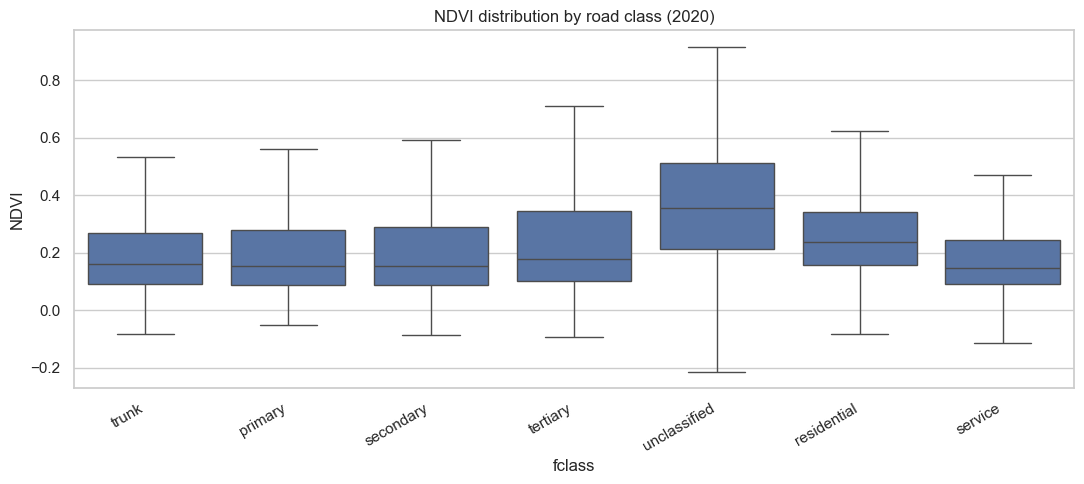

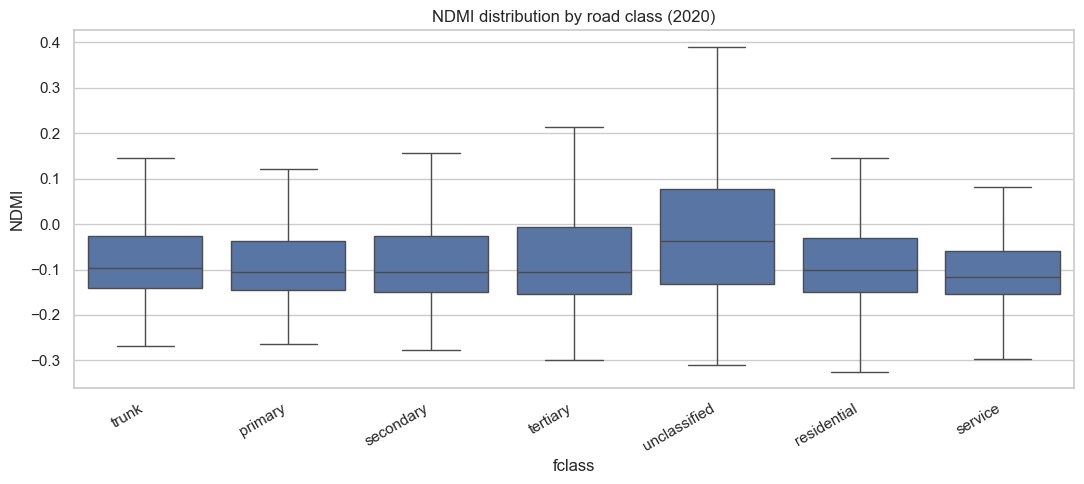

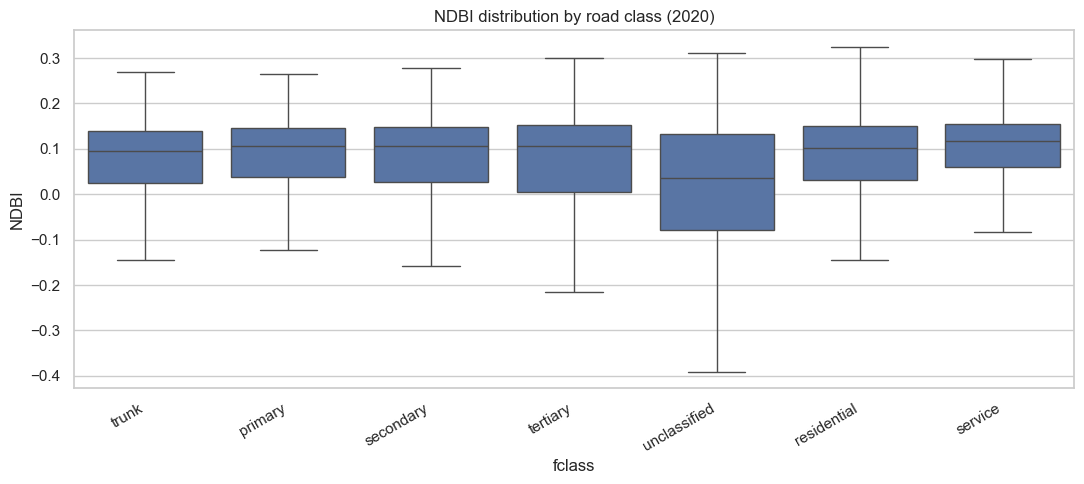

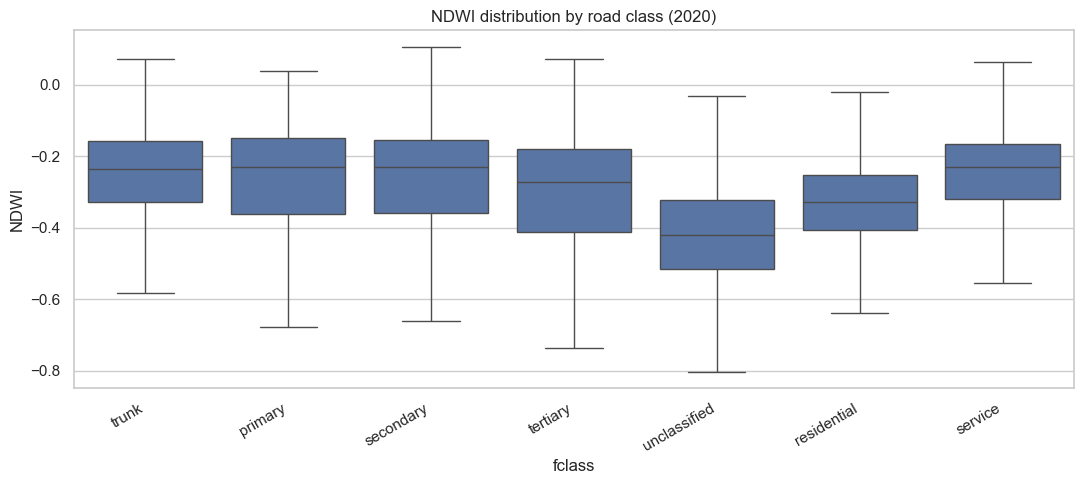

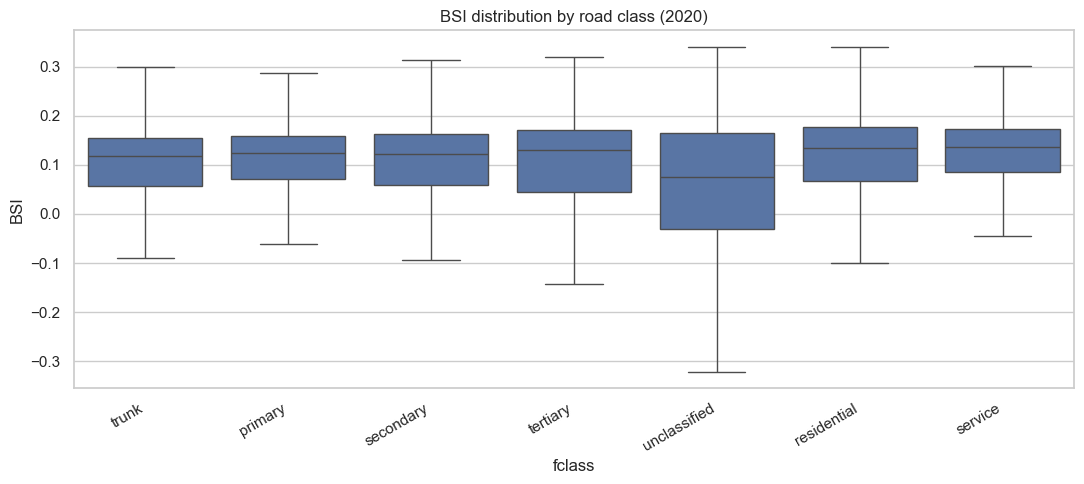

In [9]:
# Cell 9 — Boxplots by class (all indices)
for c in idx_cols:
    plt.figure(figsize=(11, 5))
    sns.boxplot(data=df, x="fclass", y=c, showfliers=False)
    plt.title(f"{c} distribution by road class (2020)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


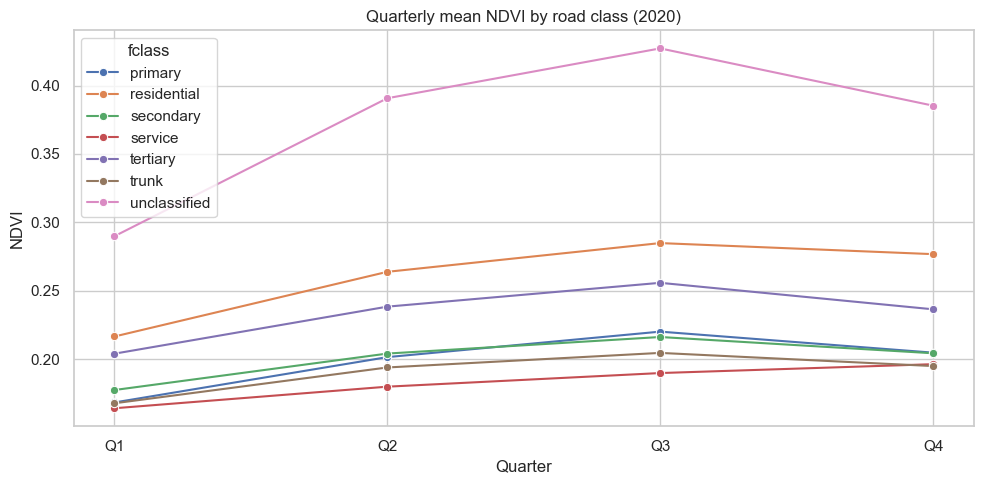

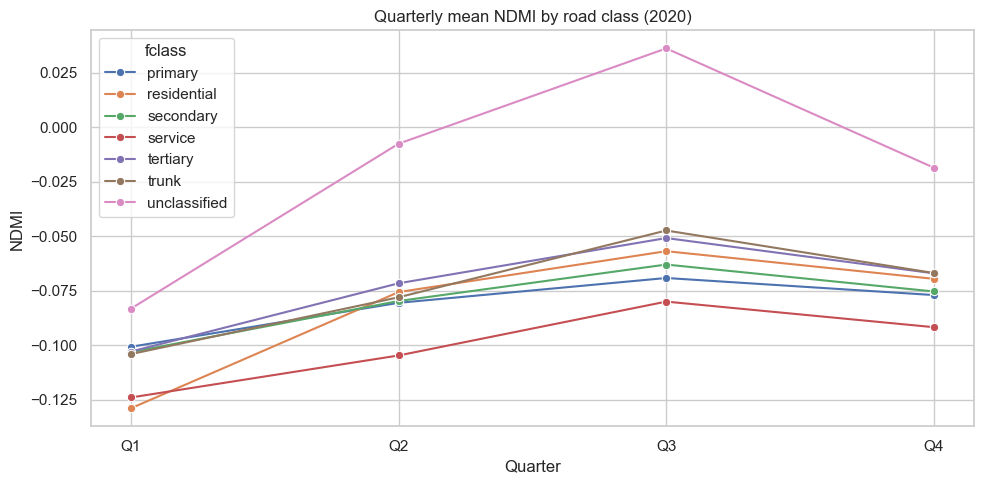

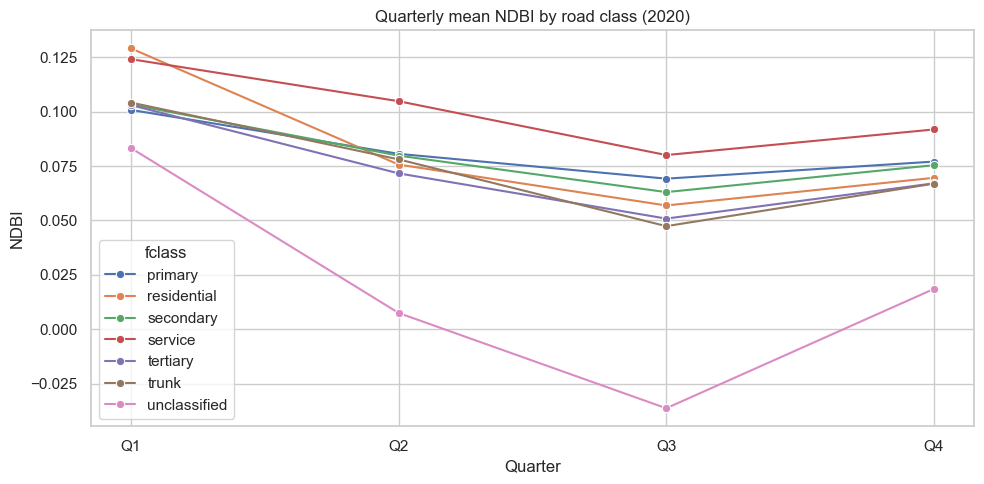

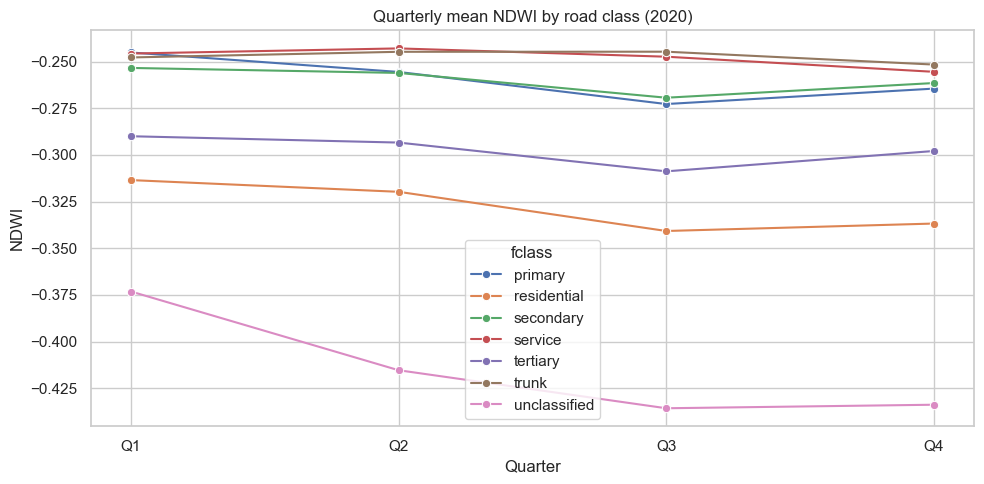

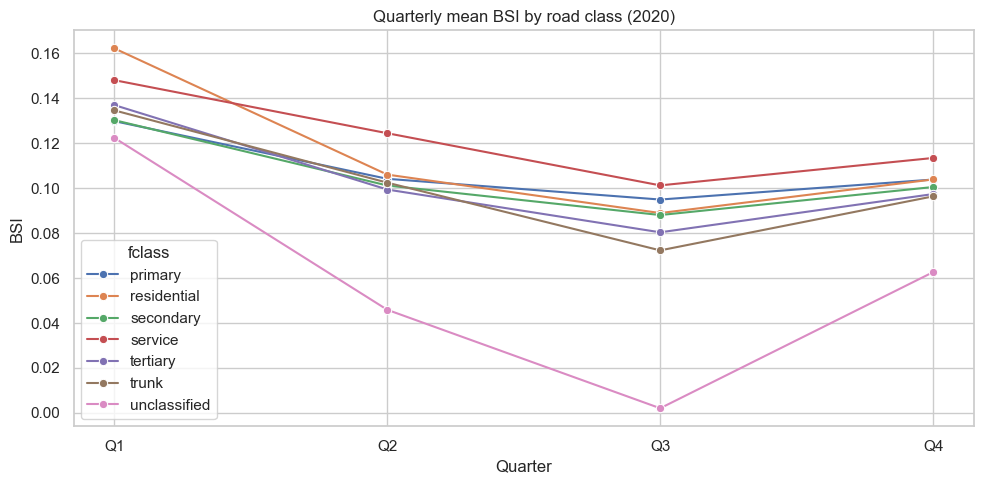

In [10]:
# Cell 10 — Quarterly mean trends by class
q_stats = (
    df.groupby(["fclass", "qnum"])[idx_cols]
    .mean()
    .reset_index()
)

for c in idx_cols:
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=q_stats, x="qnum", y=c, hue="fclass", marker="o")
    plt.title(f"Quarterly mean {c} by road class (2020)")
    plt.xlabel("Quarter")
    plt.xticks([1, 2, 3, 4], ["Q1", "Q2", "Q3", "Q4"])
    plt.tight_layout()
    plt.show()


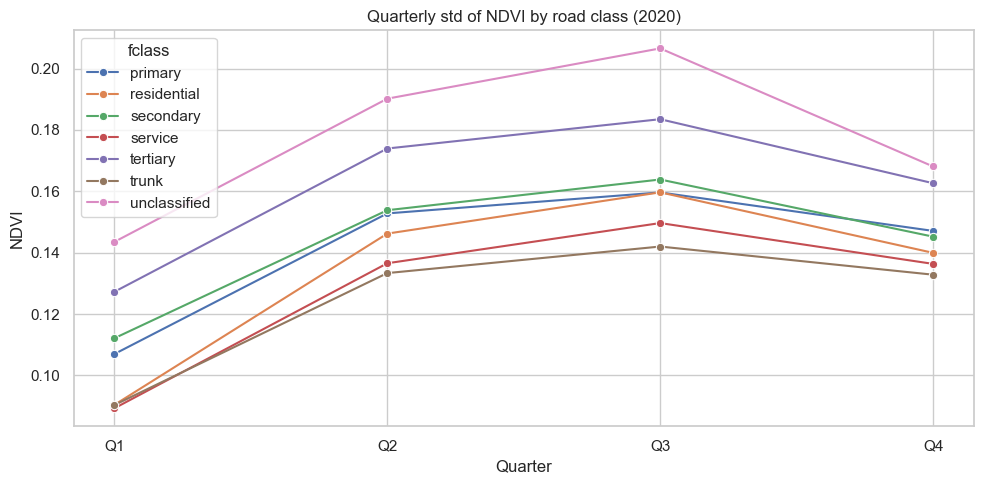

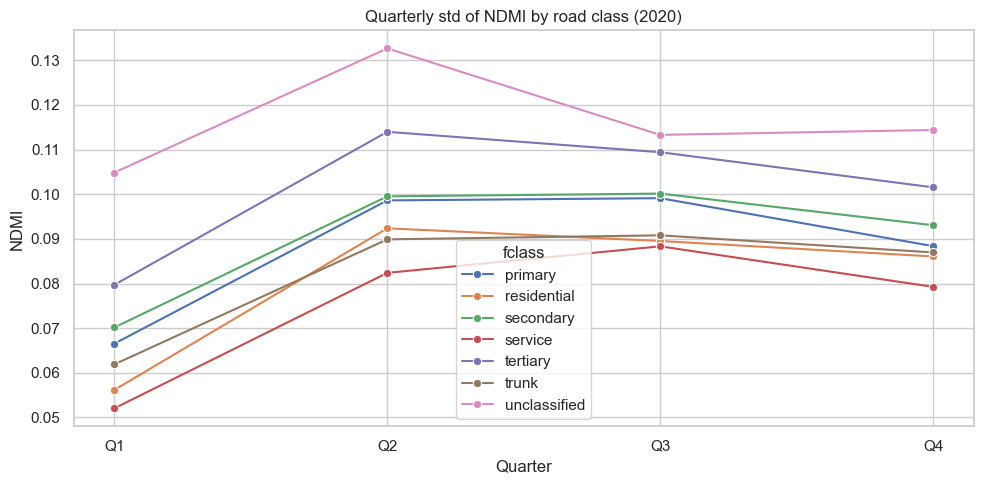

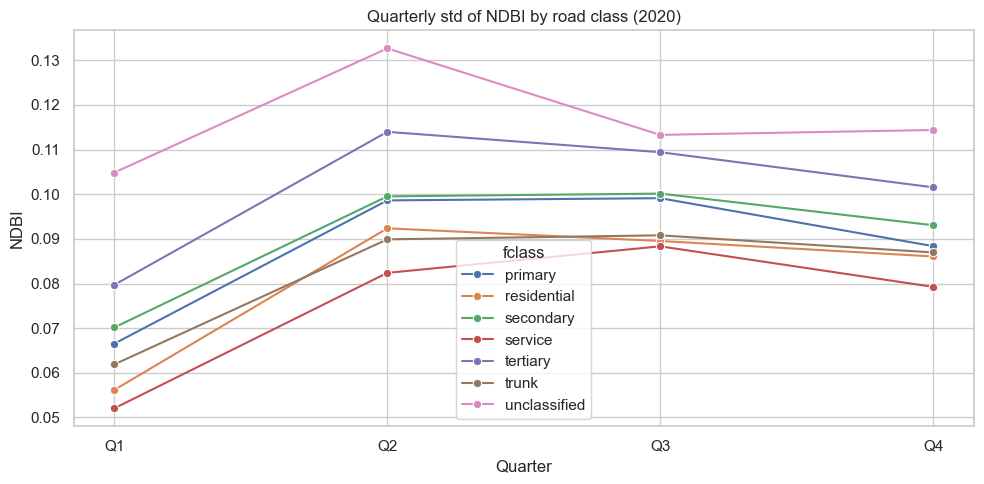

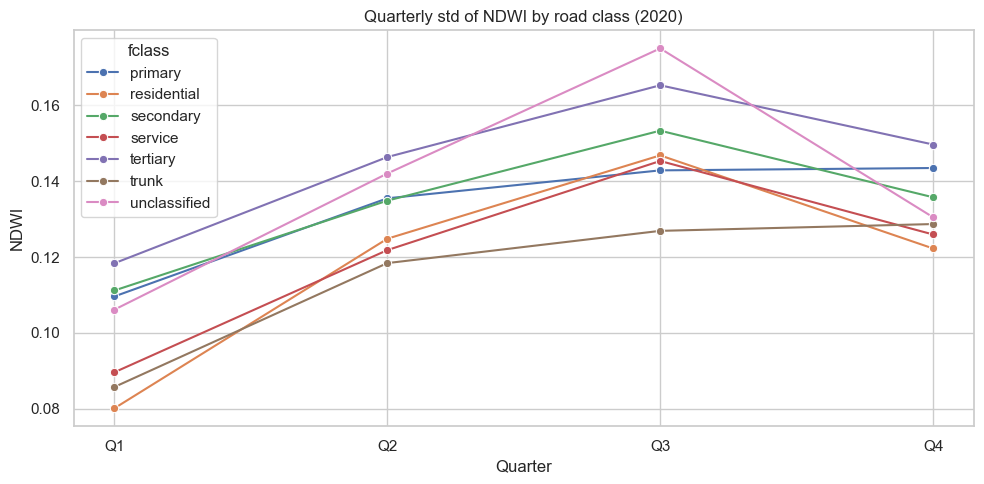

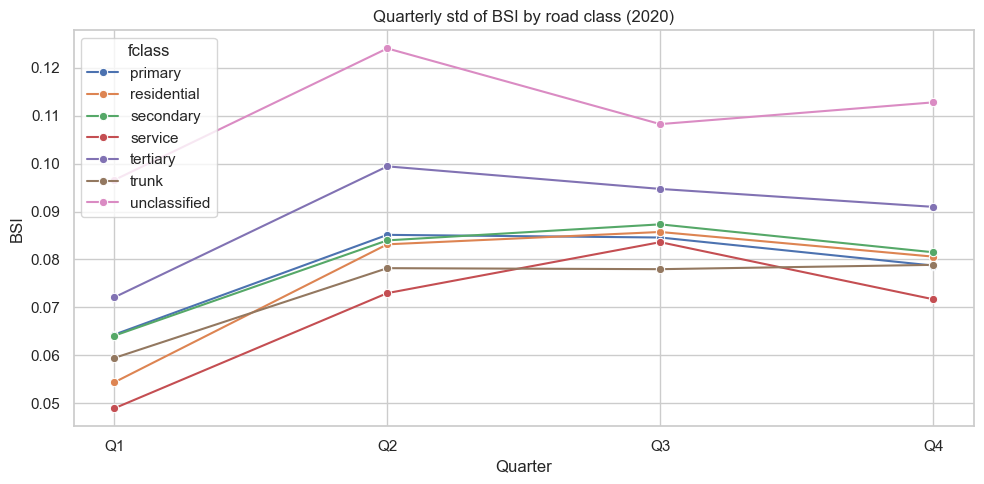

In [11]:
# Cell 11 — Quarterly variability (std) by class
q_std = (
    df.groupby(["fclass", "qnum"])[idx_cols]
    .std()
    .reset_index()
)

for c in idx_cols:
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=q_std, x="qnum", y=c, hue="fclass", marker="o")
    plt.title(f"Quarterly std of {c} by road class (2020)")
    plt.xlabel("Quarter")
    plt.xticks([1, 2, 3, 4], ["Q1", "Q2", "Q3", "Q4"])
    plt.tight_layout()
    plt.show()


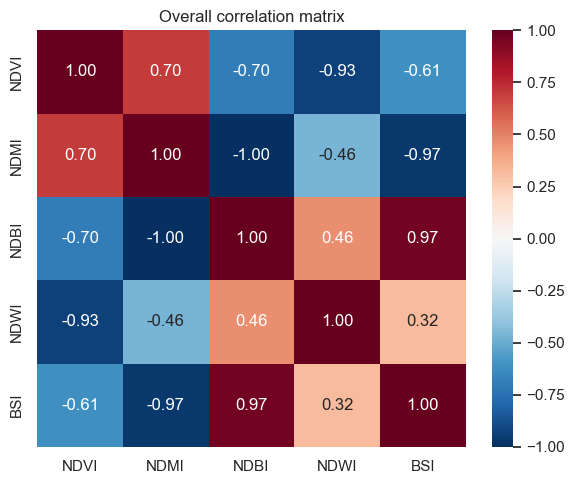

In [15]:
# Cell 12 — Overall correlation matrix heatmap
corr = df[idx_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Overall correlation matrix")
plt.tight_layout()
plt.show()


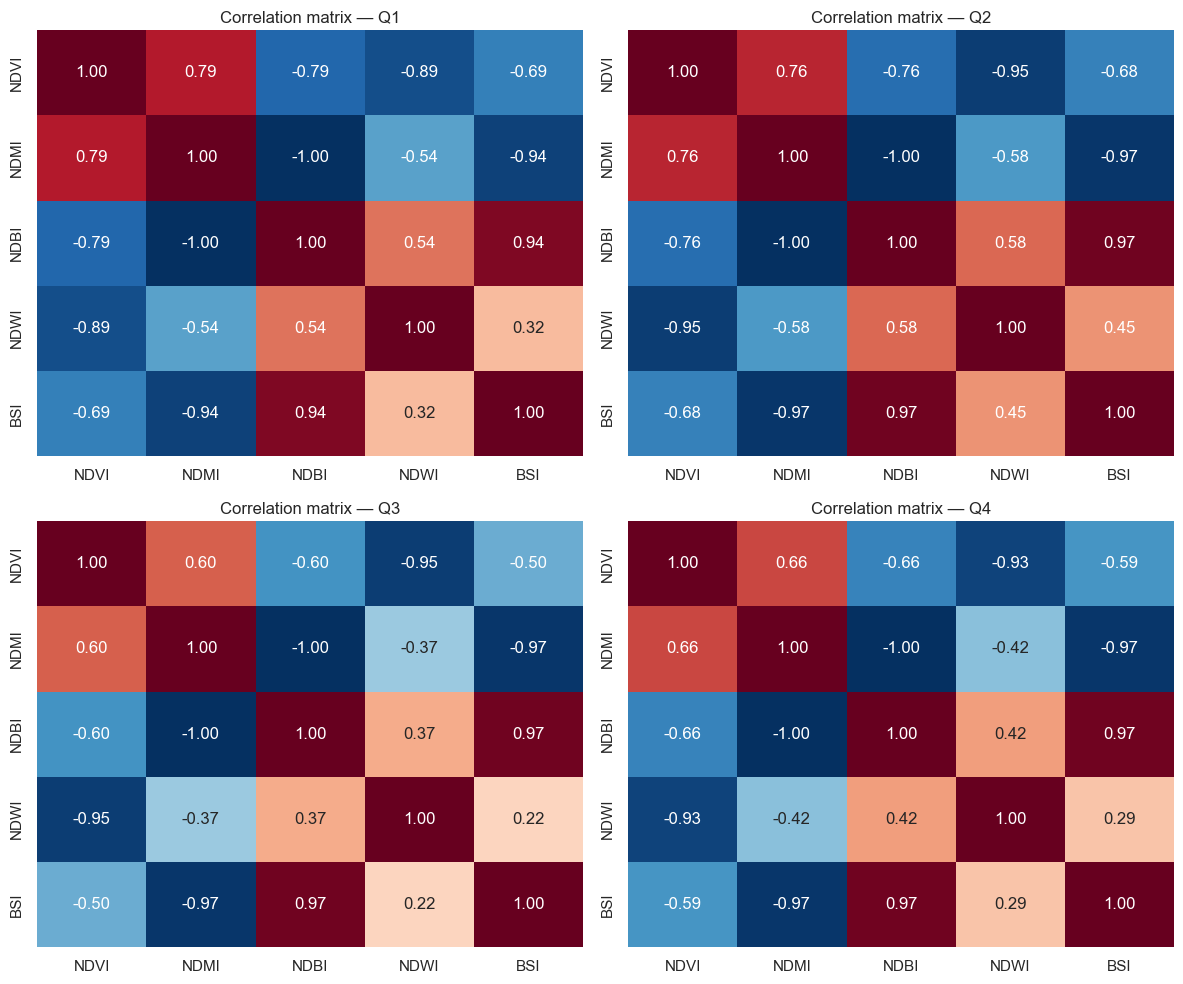

In [13]:
# Cell 13 — Correlation matrix by quarter (Q1–Q4)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, q in enumerate([1, 2, 3, 4]):
    sub = df[df["qnum"] == q]
    cmat = sub[idx_cols].corr()
    sns.heatmap(cmat, annot=True, cmap="RdBu_r", center=0, fmt=".2f", ax=axes[i], cbar=False)
    axes[i].set_title(f"Correlation matrix — Q{q}")

plt.tight_layout()
plt.show()


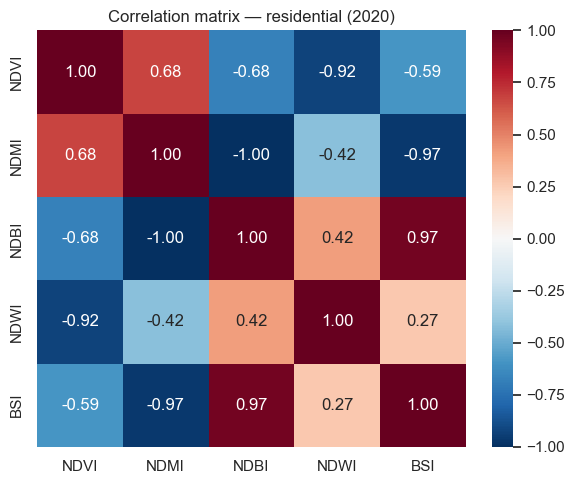

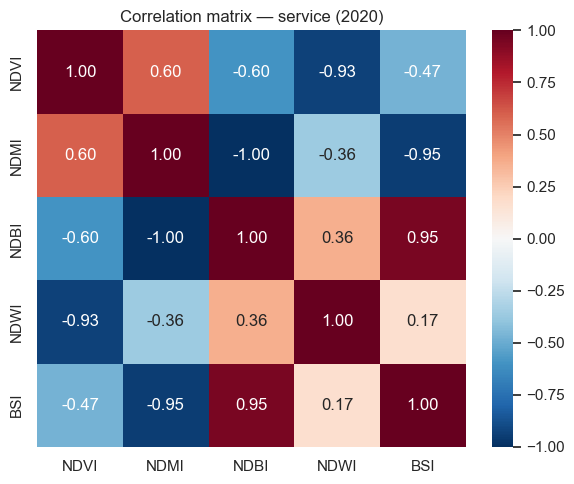

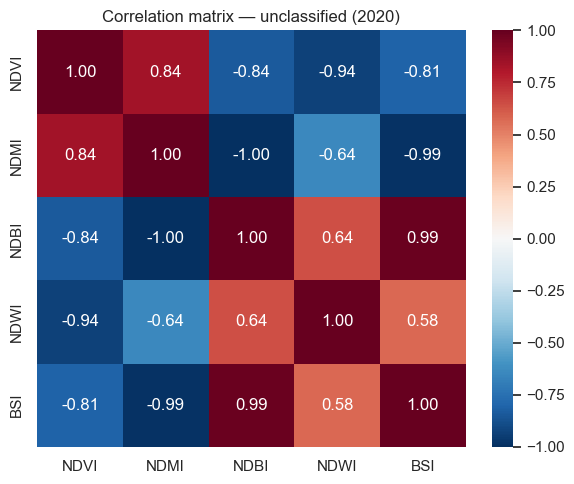

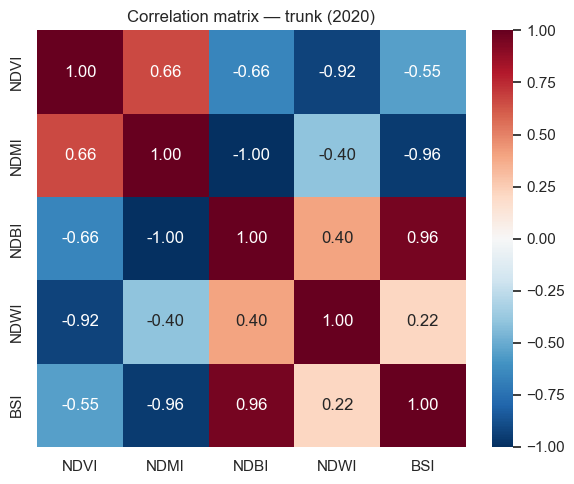

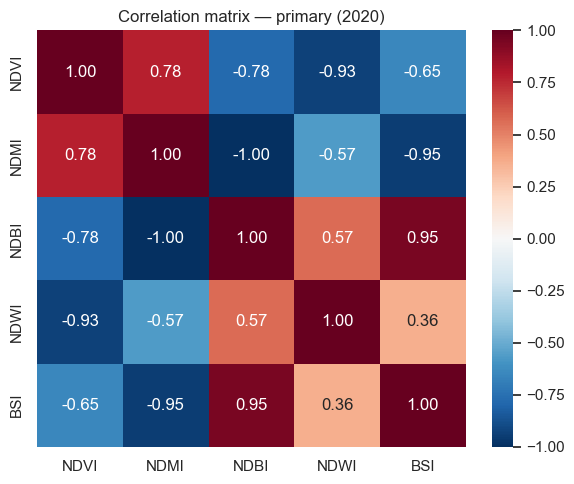

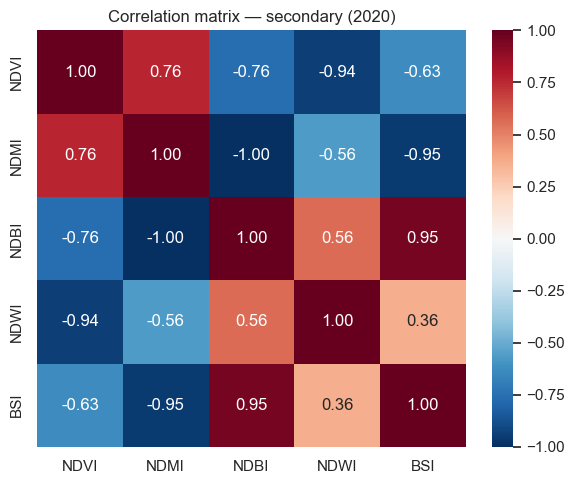

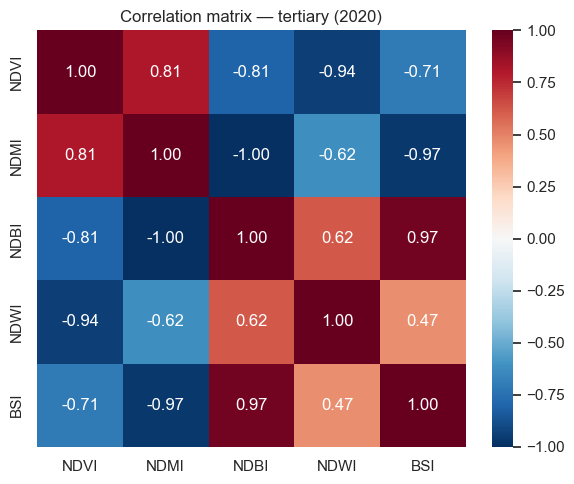

In [14]:
# Cell 14 — Optional: class-level correlation matrices
for cls in keep_classes:
    sub = df[df["fclass"] == cls]
    if len(sub) < 30:
        continue
    plt.figure(figsize=(6, 5))
    sns.heatmap(sub[idx_cols].corr(), annot=True, cmap="RdBu_r", center=0, fmt=".2f")
    plt.title(f"Correlation matrix — {cls} (2020)")
    plt.tight_layout()
    plt.show()


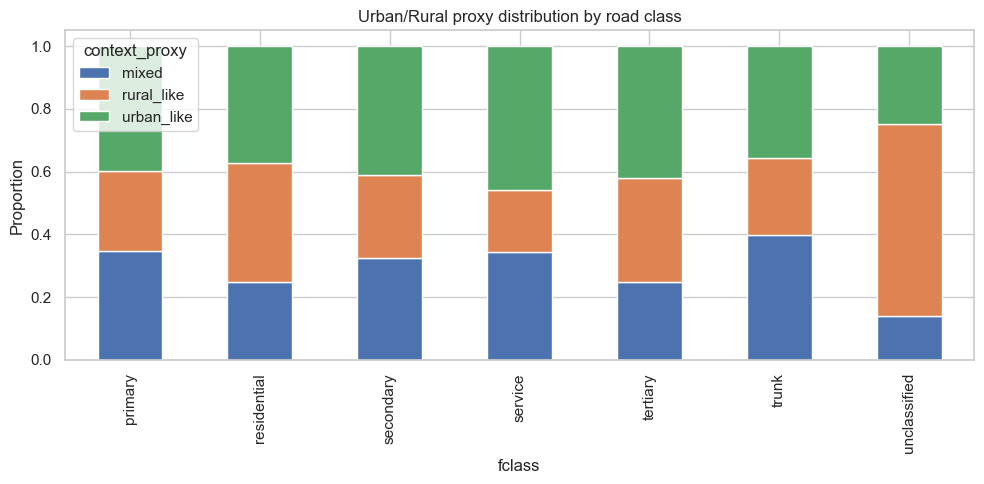

In [23]:
# Urban/rural proxy (NDVI + NDBI thresholds)
# Use overall distribution in df
ndbi_thr = df["NDBI"].quantile(0.6)
ndvi_thr = df["NDVI"].quantile(0.6)

def urban_rural(row):
    if row["NDBI"] >= ndbi_thr and row["NDVI"] <= ndvi_thr:
        return "urban_like"
    elif row["NDVI"] >= ndvi_thr and row["NDBI"] <= ndbi_thr:
        return "rural_like"
    else:
        return "mixed"

df["context_proxy"] = df.apply(urban_rural, axis=1)

proxy_counts = pd.crosstab(df["fclass"], df["context_proxy"], normalize="index")
proxy_counts

# Plot proxy proportions
proxy_counts.plot(kind="bar", stacked=True, figsize=(10,5))
plt.ylabel("Proportion")
plt.title("Urban/Rural proxy distribution by road class")
plt.tight_layout()
plt.show()
